In [1]:
import time
import pandas as pd
import json
import numpy as np
from datetime import datetime
from datetime import timezone
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from matplotlib.colors import ListedColormap
import numpy as np
# import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [2]:
def remove_specific_cycles(data_loader, indices_to_remove):
    """
    Excludes specific indices from every key in the dataset.
    indices_to_remove: list of integers (e.g., [1, 3, 6])
    """
    cleaned_data = {}
    
    for key in data_loader.files:
        original_list = list(data_loader[key])
        # Keep only the items whose index is NOT in our 'remove' list
        cleaned_data[key] = [
            cycle for i, cycle in enumerate(original_list) 
            if i not in indices_to_remove
        ]
        
    return cleaned_data

def get_cycle_stats(data_source, param_prefix, leg, norm_points=100):
    """
    Interpolates cycles for a specific leg/parameter and calculates mean/std.
    """
    key = f'{param_prefix}_{leg}'
    if key not in data_source:
        return None, None, None

    raw_cycles = data_source[key]
    normalized_list = []
    

    for j, cycle in enumerate(raw_cycles):
            
        x_old = np.linspace(0, 100, len(cycle))
        x_new = np.linspace(0, 100, norm_points)
        norm_cycle = np.interp(x_new, x_old, cycle)
        normalized_list.append(norm_cycle)
    
    if not normalized_list:
        return None, None, None

    norm_matrix = np.array(normalized_list)
    mean_vals = np.mean(norm_matrix, axis=0)
    std_vals = np.std(norm_matrix, axis=0)
    x_axis = np.linspace(0, 100, norm_points)

    return x_axis, mean_vals, std_vals

In [3]:
water_1_df = np.load('walk_in_water_1.npz', allow_pickle=True)
water_2_df = np.load('walk_in_water_2.npz', allow_pickle=True) # Fixed
ground_1_df = np.load('walk_in_ground_1.npz', allow_pickle=True)
ground_1_df.files

['stiffness_FR',
 'stiffness_BR',
 'stiffness_FL',
 'stiffness_BL',
 'damping_FR',
 'damping_BR',
 'damping_FL',
 'damping_BL',
 'torque_feedforward_FR',
 'torque_feedforward_BR',
 'torque_feedforward_FL',
 'torque_feedforward_BL']

In [4]:
water_1 = remove_specific_cycles(water_1_df, indices_to_remove=[0, 9])
water_2 = remove_specific_cycles(water_2_df, indices_to_remove=[0])
ground_1 = remove_specific_cycles(ground_1_df, indices_to_remove=[0])
transition_1 = remove_specific_cycles(np.load('transition_2.npz', allow_pickle=True), indices_to_remove=[])

# Plot show

## Stiffness

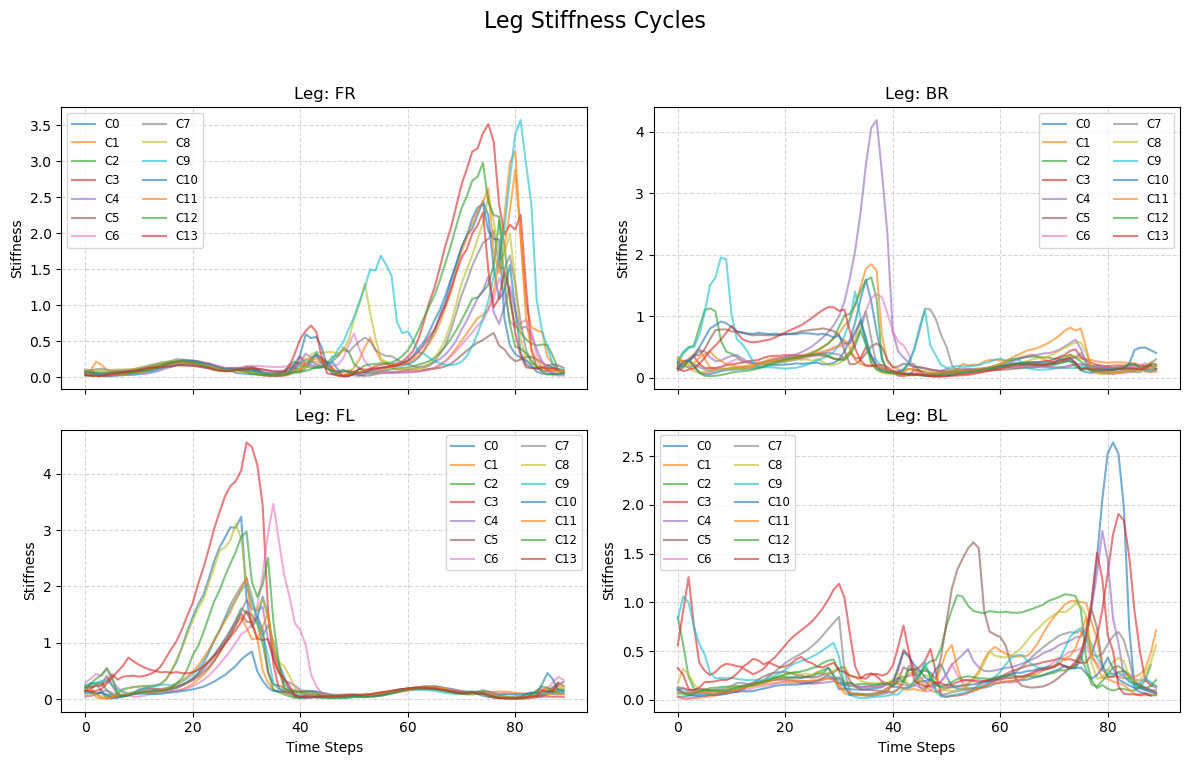

In [5]:
data = ground_1

legs = ['FR', 'BR', 'FL', 'BL'] # Arranged for natural layout
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
axes = axes.flatten()

for i, leg in enumerate(legs):
    key = f'stiffness_{leg}'
    if key in data:
        # Plot every cycle in the buffer for this leg
        for j, cycle in enumerate(data[key]):
            axes[i].plot(cycle, alpha=0.6, label=f'C{j}')
        
        axes[i].set_title(f'Leg: {leg}')
        axes[i].set_ylabel('Stiffness')
        axes[i].grid(True, linestyle='--', alpha=0.5)
        axes[i].legend(fontsize='small', ncol=2)


# Global labels
fig.suptitle('Leg Stiffness Cycles', fontsize=16)
for ax in axes[2:]: ax.set_xlabel('Time Steps')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

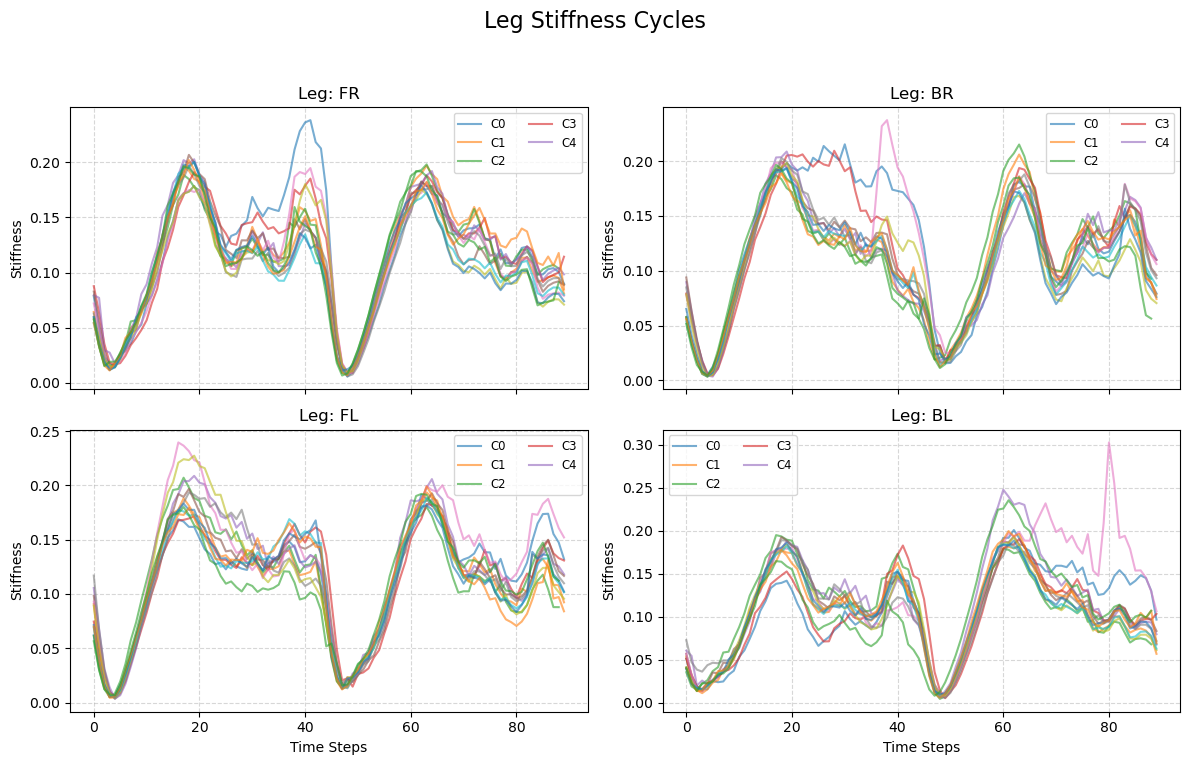

In [6]:
data = water_1

legs = ['FR', 'BR', 'FL', 'BL'] # Arranged for natural layout
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
axes = axes.flatten()

for i, leg in enumerate(legs):
    key = f'stiffness_{leg}'
    if key in data:
        # Plot every cycle in the buffer for this leg
        for j, cycle in enumerate(data[key]):
            axes[i].plot(cycle, alpha=0.6, label=f'C{j}' if j < 5 else "")
        
        axes[i].set_title(f'Leg: {leg}')
        axes[i].set_ylabel('Stiffness')
        axes[i].grid(True, linestyle='--', alpha=0.5)
        axes[i].legend(fontsize='small', ncol=2)


# Global labels
fig.suptitle('Leg Stiffness Cycles', fontsize=16)
for ax in axes[2:]: ax.set_xlabel('Time Steps')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

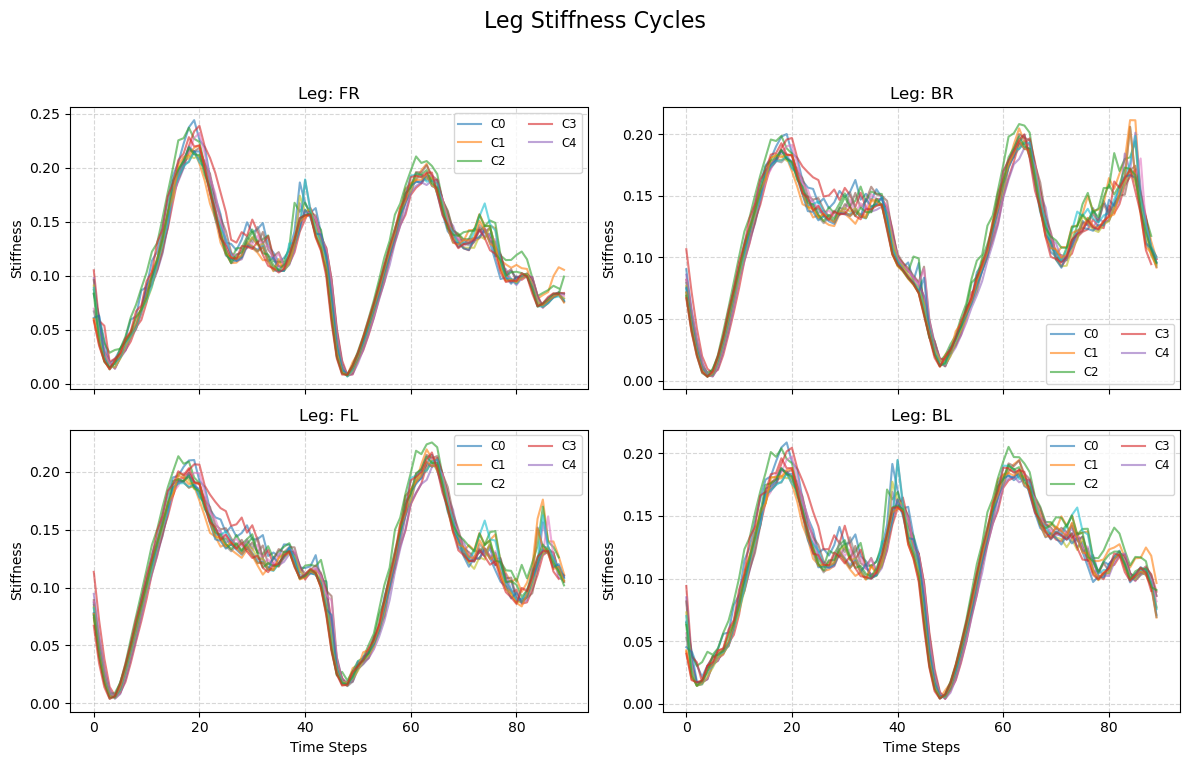

In [7]:
data = water_2

legs = ['FR', 'BR', 'FL', 'BL'] # Arranged for natural layout
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
axes = axes.flatten()

for i, leg in enumerate(legs):
    key = f'stiffness_{leg}'
    if key in data:
        # Plot every cycle in the buffer for this leg
        for j, cycle in enumerate(data[key]):
            axes[i].plot(cycle, alpha=0.6, label=f'C{j}' if j < 5 else "")
        
        axes[i].set_title(f'Leg: {leg}')
        axes[i].set_ylabel('Stiffness')
        axes[i].grid(True, linestyle='--', alpha=0.5)
        axes[i].legend(fontsize='small', ncol=2)

# Global labels
fig.suptitle('Leg Stiffness Cycles', fontsize=16)
for ax in axes[2:]: ax.set_xlabel('Time Steps')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Damping

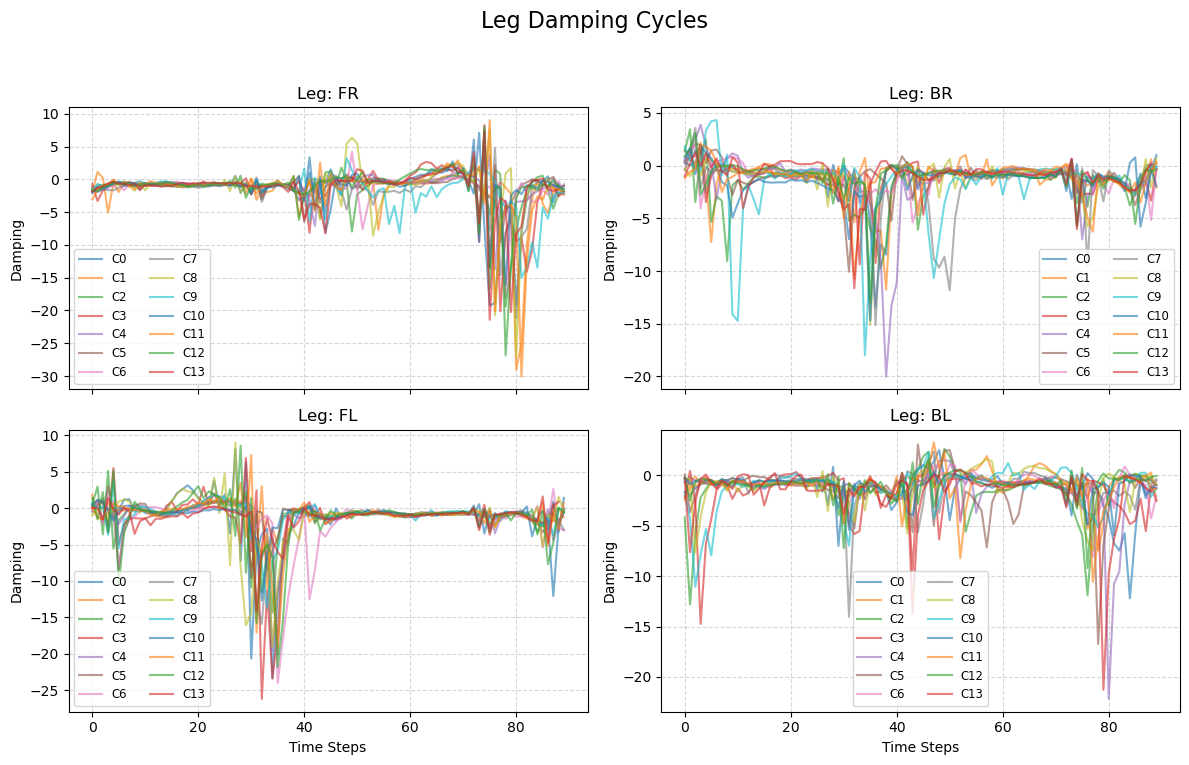

In [8]:
data = ground_1

legs = ['FR', 'BR', 'FL', 'BL'] # Arranged for natural layout
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
axes = axes.flatten()

for i, leg in enumerate(legs):
    key = f'damping_{leg}'
    if key in data:
        # Plot every cycle in the buffer for this leg
        for j, cycle in enumerate(data[key]):
            axes[i].plot(cycle, alpha=0.6, label=f'C{j}')
        
        axes[i].set_title(f'Leg: {leg}')
        axes[i].set_ylabel('Damping')
        axes[i].grid(True, linestyle='--', alpha=0.5)
        axes[i].legend(fontsize='small', ncol=2)

# Global labels
fig.suptitle('Leg Damping Cycles', fontsize=16)
for ax in axes[2:]: ax.set_xlabel('Time Steps')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

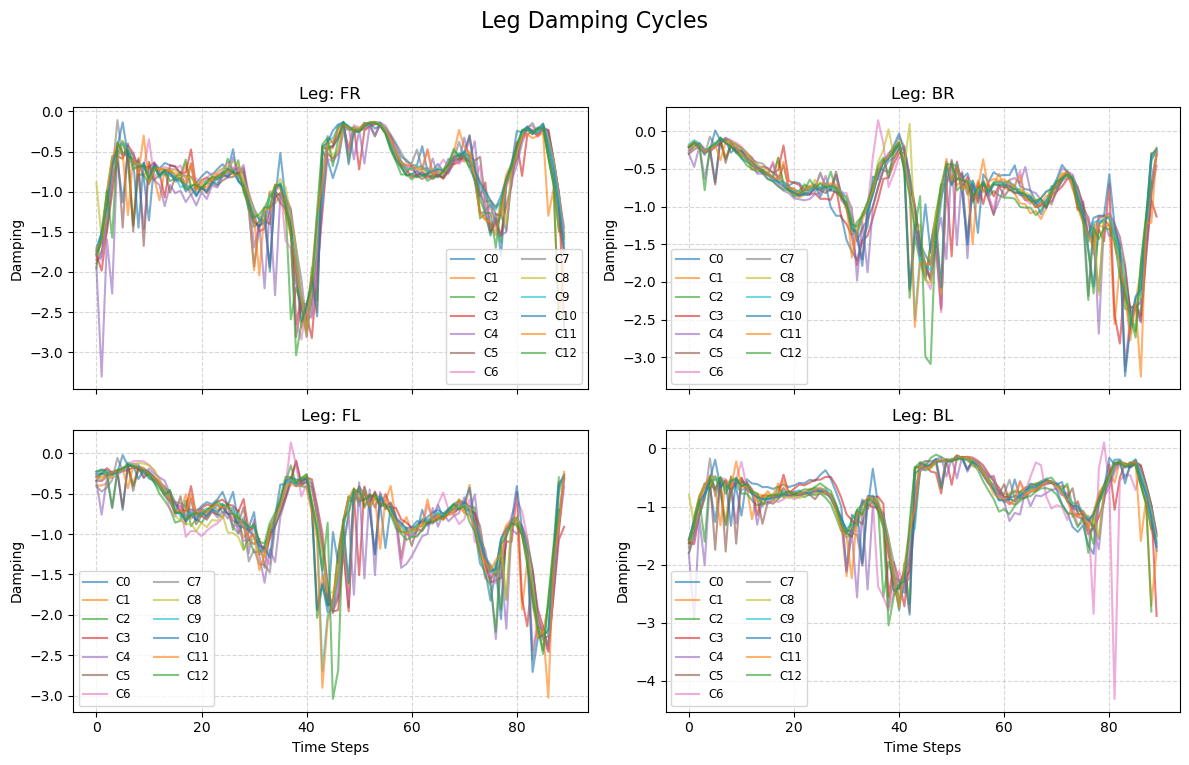

In [9]:
data = water_1

legs = ['FR', 'BR', 'FL', 'BL'] # Arranged for natural layout
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
axes = axes.flatten()

for i, leg in enumerate(legs):
    key = f'damping_{leg}'
    if key in data:
        # Plot every cycle in the buffer for this leg
        for j, cycle in enumerate(data[key]):
            axes[i].plot(cycle, alpha=0.6, label=f'C{j}')
        
        axes[i].set_title(f'Leg: {leg}')
        axes[i].set_ylabel('Damping')
        axes[i].grid(True, linestyle='--', alpha=0.5)
        axes[i].legend(fontsize='small', ncol=2)

# Global labels
fig.suptitle('Leg Damping Cycles', fontsize=16)
for ax in axes[2:]: ax.set_xlabel('Time Steps')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

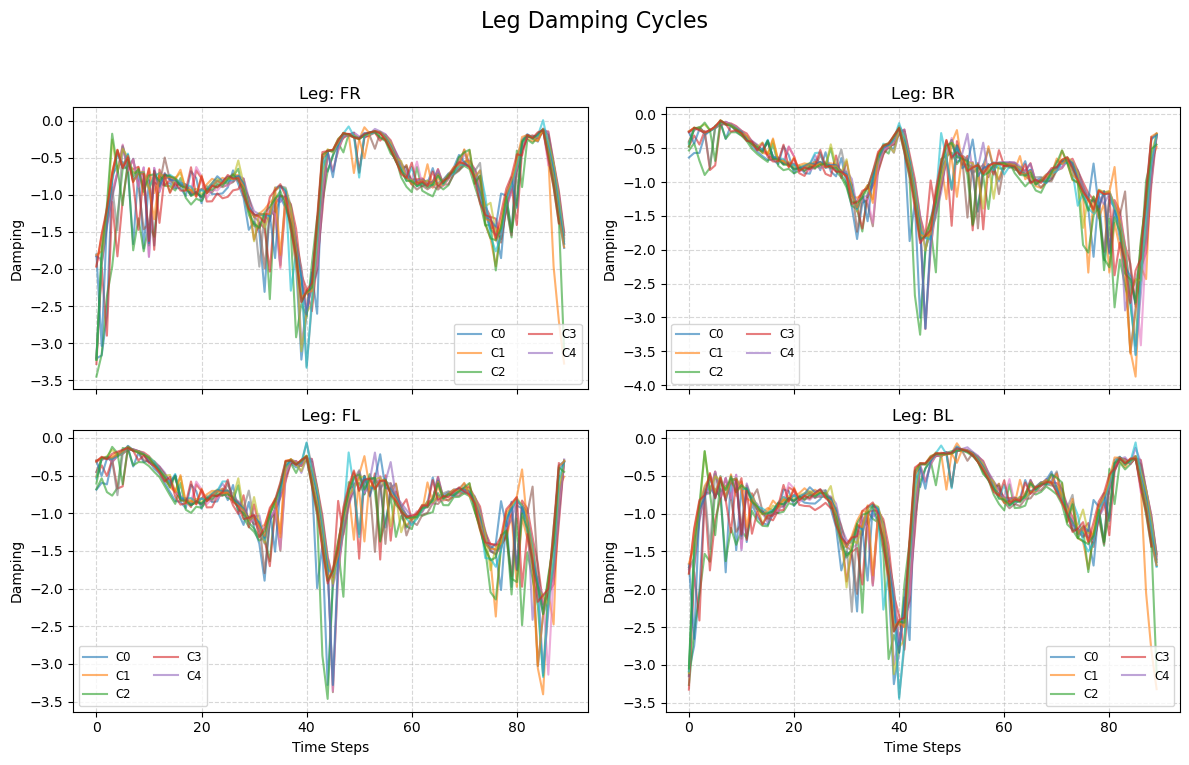

In [10]:
data = water_2

legs = ['FR', 'BR', 'FL', 'BL'] # Arranged for natural layout
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
axes = axes.flatten()

for i, leg in enumerate(legs):
    key = f'damping_{leg}'
    if key in data:
        # Plot every cycle in the buffer for this leg
        for j, cycle in enumerate(data[key]):
            axes[i].plot(cycle, alpha=0.6, label=f'C{j}' if j < 5 else "")
        
        axes[i].set_title(f'Leg: {leg}')
        axes[i].set_ylabel('Damping')
        axes[i].grid(True, linestyle='--', alpha=0.5)
        axes[i].legend(fontsize='small', ncol=2)

# Global labels
fig.suptitle('Leg Damping Cycles', fontsize=16)
for ax in axes[2:]: ax.set_xlabel('Time Steps')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Torque Feedforward

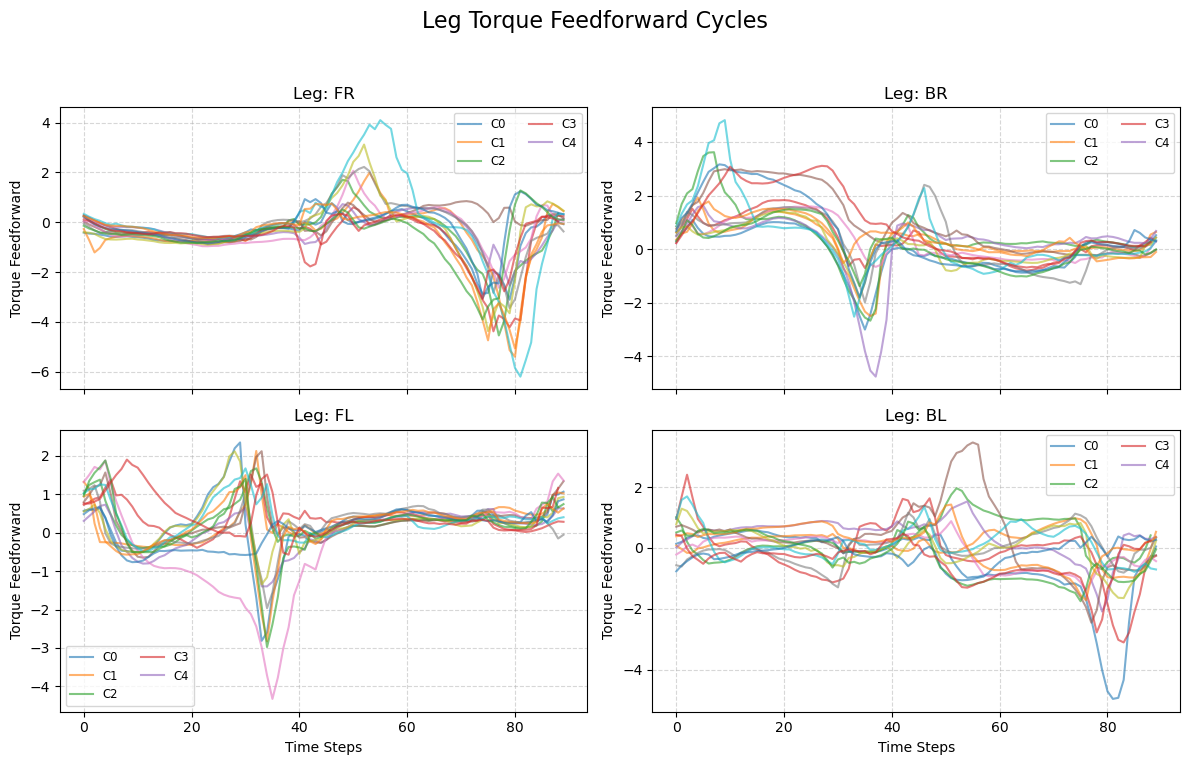

In [11]:
data = ground_1

legs = ['FR', 'BR', 'FL', 'BL'] # Arranged for natural layout
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
axes = axes.flatten()

for i, leg in enumerate(legs):
    key = f'torque_feedforward_{leg}'
    if key in data:
        # Plot every cycle in the buffer for this leg
        for j, cycle in enumerate(data[key]):
            axes[i].plot(cycle, alpha=0.6, label=f'C{j}' if j < 5 else "")
        
        axes[i].set_title(f'Leg: {leg}')
        axes[i].set_ylabel('Torque Feedforward')
        axes[i].grid(True, linestyle='--', alpha=0.5)
        axes[i].legend(fontsize='small', ncol=2)

# Global labels
fig.suptitle('Leg Torque Feedforward Cycles', fontsize=16)
for ax in axes[2:]: ax.set_xlabel('Time Steps')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

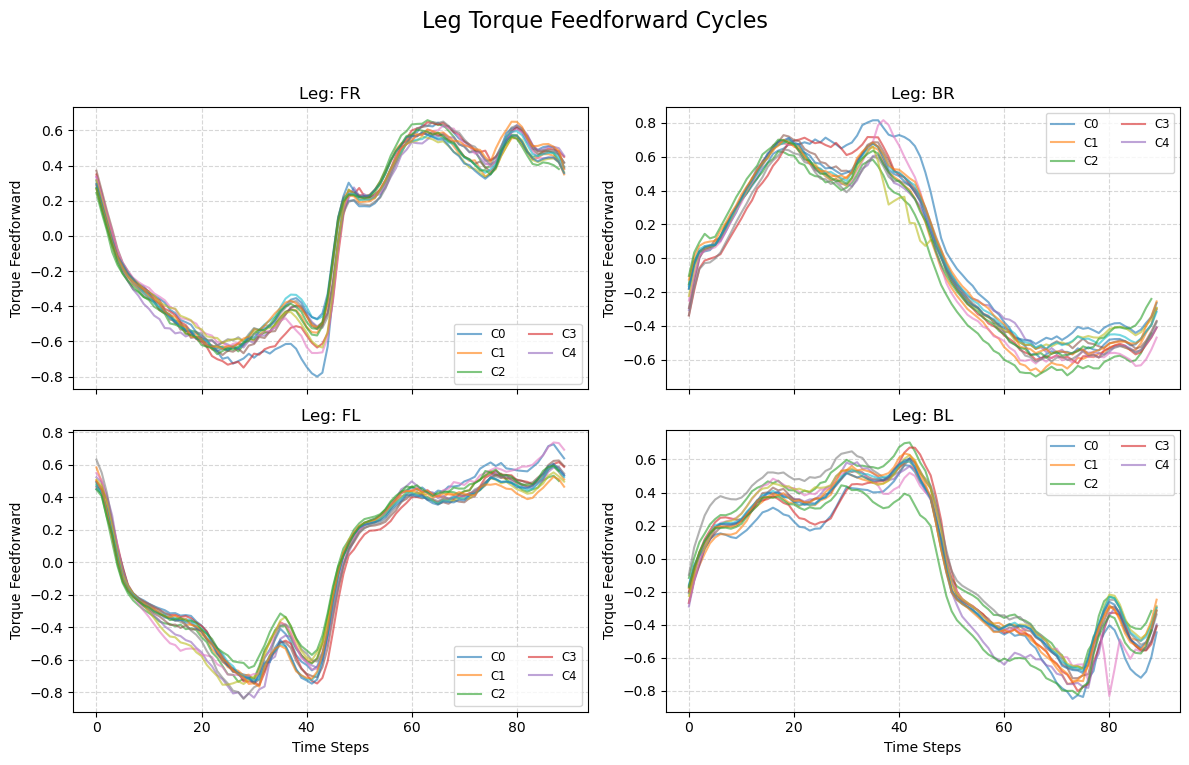

In [12]:
data = water_1

legs = ['FR', 'BR', 'FL', 'BL'] # Arranged for natural layout
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
axes = axes.flatten()

for i, leg in enumerate(legs):
    key = f'torque_feedforward_{leg}'
    if key in data:
        # Plot every cycle in the buffer for this leg
        for j, cycle in enumerate(data[key]):
            axes[i].plot(cycle, alpha=0.6, label=f'C{j}' if j < 5 else "")
        
        axes[i].set_title(f'Leg: {leg}')
        axes[i].set_ylabel('Torque Feedforward')
        axes[i].grid(True, linestyle='--', alpha=0.5)
        axes[i].legend(fontsize='small', ncol=2)

# Global labels
fig.suptitle('Leg Torque Feedforward Cycles', fontsize=16)
for ax in axes[2:]: ax.set_xlabel('Time Steps')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

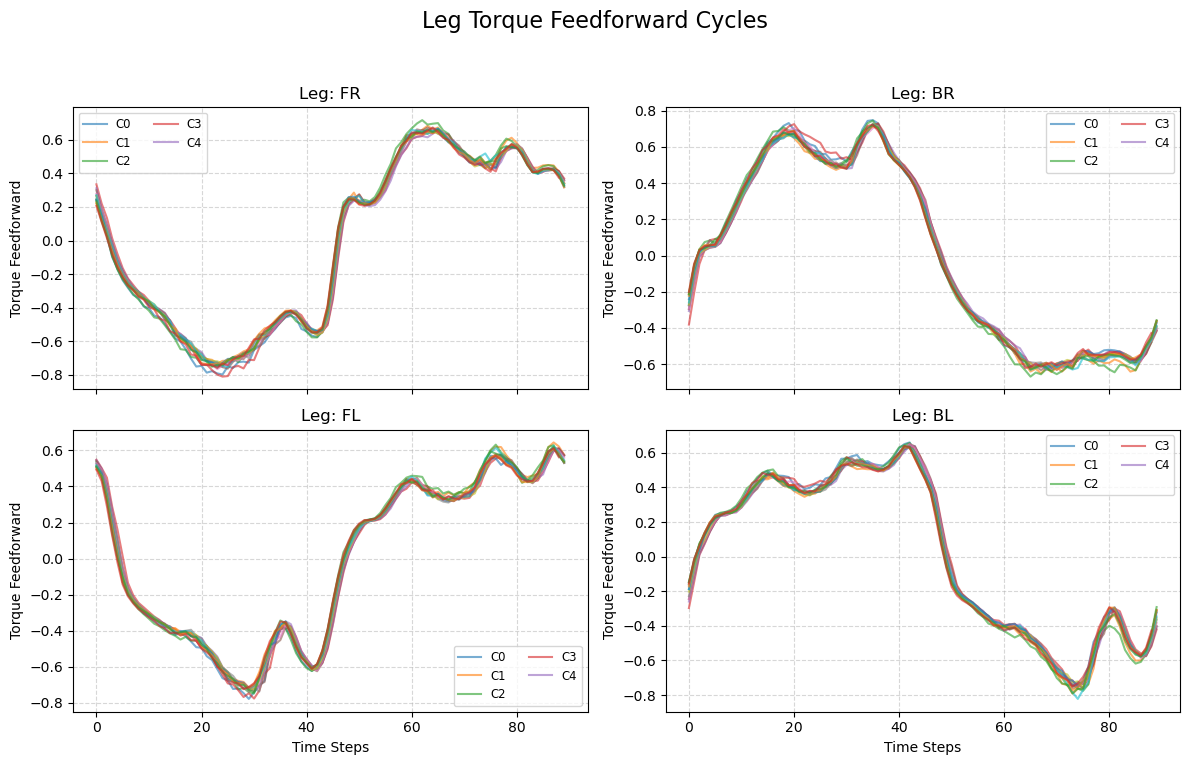

In [13]:
data = water_2

legs = ['FR', 'BR', 'FL', 'BL'] # Arranged for natural layout
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
axes = axes.flatten()

for i, leg in enumerate(legs):
    key = f'torque_feedforward_{leg}'
    if key in data:
        # Plot every cycle in the buffer for this leg
        for j, cycle in enumerate(data[key]):
            axes[i].plot(cycle, alpha=0.6, label=f'C{j}' if j < 5 else "")
        
        axes[i].set_title(f'Leg: {leg}')
        axes[i].set_ylabel('Torque Feedforward')
        axes[i].grid(True, linestyle='--', alpha=0.5)
        axes[i].legend(fontsize='small', ncol=2)

		

# Global labels
fig.suptitle('Leg Torque Feedforward Cycles', fontsize=16)
for ax in axes[2:]: ax.set_xlabel('Time Steps')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Plot Process

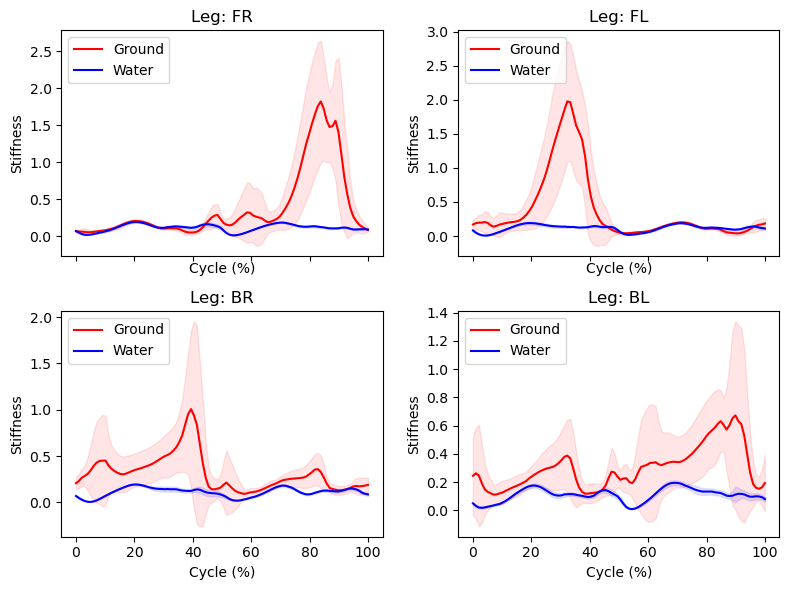

In [14]:
legs = ['FR', 'FL', 'BR', 'BL']
fig, axes = plt.subplots(2, 2, figsize=(8, 6), sharex=True)
axes = axes.flatten()

for i, leg in enumerate(legs):
	x, mean_g, std_g = get_cycle_stats(ground_1, 'stiffness', leg)
	x_w, mean_w, std_w = get_cycle_stats(water_1, 'stiffness', leg)

	if x is None or x_w is None:
		continue

	axes[i].plot(x, mean_g, color='red', label='Ground')
	axes[i].fill_between(x, mean_g - std_g, mean_g + std_g, color='red', alpha=0.1)

	axes[i].plot(x_w, mean_w, color='blue', label='Water')
	axes[i].fill_between(x_w, mean_w - std_w, mean_w + std_w, color='blue', alpha=0.1)

	axes[i].set_title(f'Leg: {leg}')
	axes[i].legend(loc='upper left')

	axes[i].set_xlabel('Cycle (%)')
	axes[i].set_ylabel('Stiffness')

plt.tight_layout()
plt.show()

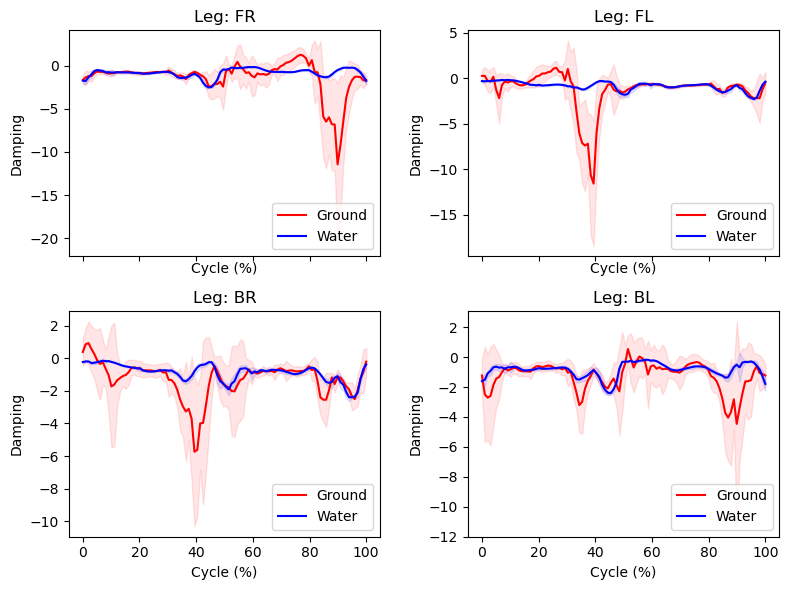

In [15]:
legs = ['FR', 'FL', 'BR', 'BL']
fig, axes = plt.subplots(2, 2, figsize=(8, 6), sharex=True)
axes = axes.flatten()

for i, leg in enumerate(legs):
	x, mean_g, std_g = get_cycle_stats(ground_1, 'damping', leg)
	x_w, mean_w, std_w = get_cycle_stats(water_1, 'damping', leg)

	if x is None or x_w is None:
		continue

	axes[i].plot(x, mean_g, color='red', label='Ground')
	axes[i].fill_between(x, mean_g - std_g, mean_g + std_g, color='red', alpha=0.1)

	axes[i].plot(x_w, mean_w, color='blue', label='Water')
	axes[i].fill_between(x_w, mean_w - std_w, mean_w + std_w, color='blue', alpha=0.1)

	axes[i].set_title(f'Leg: {leg}')
	axes[i].legend(loc='lower right')

	axes[i].set_xlabel('Cycle (%)')
	axes[i].set_ylabel('Damping')


plt.tight_layout()
plt.show()

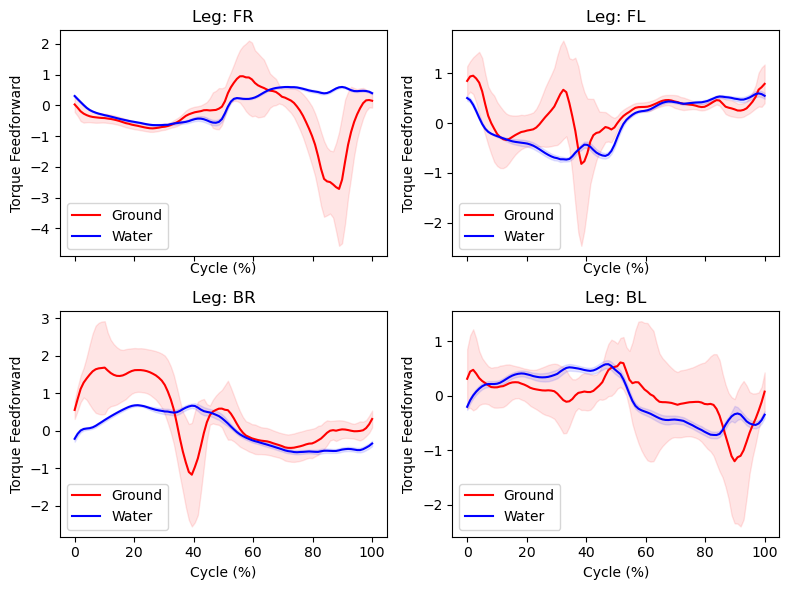

In [16]:
legs = ['FR', 'FL', 'BR', 'BL']
fig, axes = plt.subplots(2, 2, figsize=(8, 6), sharex=True)
axes = axes.flatten()

for i, leg in enumerate(legs):
	x, mean_g, std_g = get_cycle_stats(ground_1, 'torque_feedforward', leg)
	x_w, mean_w, std_w = get_cycle_stats(water_1, 'torque_feedforward', leg)

	if x is None or x_w is None:
		continue

	axes[i].plot(x, mean_g, color='red', label='Ground')
	axes[i].fill_between(x, mean_g - std_g, mean_g + std_g, color='red', alpha=0.1)

	axes[i].plot(x_w, mean_w, color='blue', label='Water')
	axes[i].fill_between(x_w, mean_w - std_w, mean_w + std_w, color='blue', alpha=0.1)

	axes[i].set_title(f'Leg: {leg}')
	axes[i].legend(loc='lower left')

	axes[i].set_xlabel('Cycle (%)')
	axes[i].set_ylabel('Torque Feedforward')


plt.tight_layout()
plt.show()

# DTW-K-mean

In [17]:
# stiffness_all_cycle = {}
# stiffness_all_cycle['stiffness_FR'] = ground_1['stiffness_FR'] + water_1['stiffness_FR'] + transition_1['stiffness_FR']
# stiffness_all_cycle['stiffness_BR'] = ground_1['stiffness_BR'] + water_1['stiffness_BR'] + transition_1['stiffness_BR']
# stiffness_all_cycle['stiffness_FL'] = ground_1['stiffness_FL'] + water_1['stiffness_FL'] + transition_1['stiffness_FL']
# stiffness_all_cycle['stiffness_BL'] = ground_1['stiffness_BL'] + water_1['stiffness_BL'] + transition_1['stiffness_BL']


# damping_all_cycle = {}
# damping_all_cycle['damping_FR'] = ground_1['damping_FR'] + water_1['damping_FR'] + transition_1['damping_FR']
# damping_all_cycle['damping_BR'] = ground_1['damping_BR'] + water_1['damping_BR'] + transition_1['damping_BR']
# damping_all_cycle['damping_FL'] = ground_1['damping_FL'] + water_1['damping_FL'] + transition_1['damping_FL']
# damping_all_cycle['damping_BL'] = ground_1['damping_BL'] + water_1['damping_BL'] + transition_1['damping_BL']

# torque_feedforward_all_cycle = {}
# torque_feedforward_all_cycle['torque_feedforward_FR'] = ground_1['torque_feedforward_FR'] + water_1['torque_feedforward_FR'] + transition_1['torque_feedforward_FR']
# torque_feedforward_all_cycle['torque_feedforward_BR'] = ground_1['torque_feedforward_BR'] + water_1['torque_feedforward_BR'] + transition_1['torque_feedforward_BR']
# torque_feedforward_all_cycle['torque_feedforward_FL'] = ground_1['torque_feedforward_FL'] + water_1['torque_feedforward_FL'] + transition_1['torque_feedforward_FL']
# torque_feedforward_all_cycle['torque_feedforward_BL'] = ground_1['torque_feedforward_BL'] + water_1['torque_feedforward_BL'] + transition_1['torque_feedforward_BL']	 

# print(f"Number of cycles: {len(stiffness_all_cycle['stiffness_FR'])}")

In [18]:
stiffness_all_cycle = {}
stiffness_all_cycle['stiffness_FR'] = ground_1['stiffness_FR'] + water_1['stiffness_FR'] 
stiffness_all_cycle['stiffness_BR'] = ground_1['stiffness_BR'] + water_1['stiffness_BR'] 
stiffness_all_cycle['stiffness_FL'] = ground_1['stiffness_FL'] + water_1['stiffness_FL'] 
stiffness_all_cycle['stiffness_BL'] = ground_1['stiffness_BL'] + water_1['stiffness_BL'] 


damping_all_cycle = {}
damping_all_cycle['damping_FR'] = ground_1['damping_FR'] + water_1['damping_FR'] 
damping_all_cycle['damping_BR'] = ground_1['damping_BR'] + water_1['damping_BR'] 
damping_all_cycle['damping_FL'] = ground_1['damping_FL'] + water_1['damping_FL'] 
damping_all_cycle['damping_BL'] = ground_1['damping_BL'] + water_1['damping_BL'] 

torque_feedforward_all_cycle = {}
torque_feedforward_all_cycle['torque_feedforward_FR'] = ground_1['torque_feedforward_FR'] + water_1['torque_feedforward_FR'] 
torque_feedforward_all_cycle['torque_feedforward_BR'] = ground_1['torque_feedforward_BR'] + water_1['torque_feedforward_BR'] 
torque_feedforward_all_cycle['torque_feedforward_FL'] = ground_1['torque_feedforward_FL'] + water_1['torque_feedforward_FL'] 
torque_feedforward_all_cycle['torque_feedforward_BL'] = ground_1['torque_feedforward_BL'] + water_1['torque_feedforward_BL'] 	 

print(f"Number of cycles: {len(stiffness_all_cycle['stiffness_FR'])}")

Number of cycles: 27


In [19]:
def resample_cycle(cycle, target_len=30):
    """Resamples a (N x 3) cycle to (target_len x 3)"""
    n_samples, n_features = cycle.shape
    new_cycle = np.zeros((target_len, n_features))
    
    old_x = np.linspace(0, 1, n_samples)
    new_x = np.linspace(0, 1, target_len)
    
    for i in range(n_features):
        new_cycle[:, i] = np.interp(new_x, old_x, cycle[:, i])
    return new_cycle


In [20]:
# 1. Structure your data from the dictionaries
X_raw = []
for k, b, tau in zip(stiffness_all_cycle['stiffness_FR'], 
                     damping_all_cycle['damping_FR'], 
                     torque_feedforward_all_cycle['torque_feedforward_FR']):
    # Each item is a (Length x 3) matrix
    X_raw.append(np.stack([k, b, tau], axis=1))

# 2. Resample all cycles to the same length (e.g., 30)
X_fixed = [resample_cycle(cycle, target_len=90) for cycle in X_raw]

# 3. Now np.array(X_fixed) will work perfectly
X_array = np.array(X_fixed) 
print(f"Unified shape: {X_array.shape}") # Should be (27, 90, 3)

Unified shape: (27, 90, 3)


In [21]:
from env_pred import TimeSeriesKMeans

model = TimeSeriesKMeans(k=2, max_iter=10, window=90)

scaled_centroids = model.fit(X_array)


Iteration 1 complete
Iteration 2 complete
Iteration 3 complete
Iteration 4 complete
Iteration 5 complete
Iteration 6 complete
Iteration 7 complete
Iteration 8 complete
Iteration 9 complete
Iteration 10 complete


## Visualize

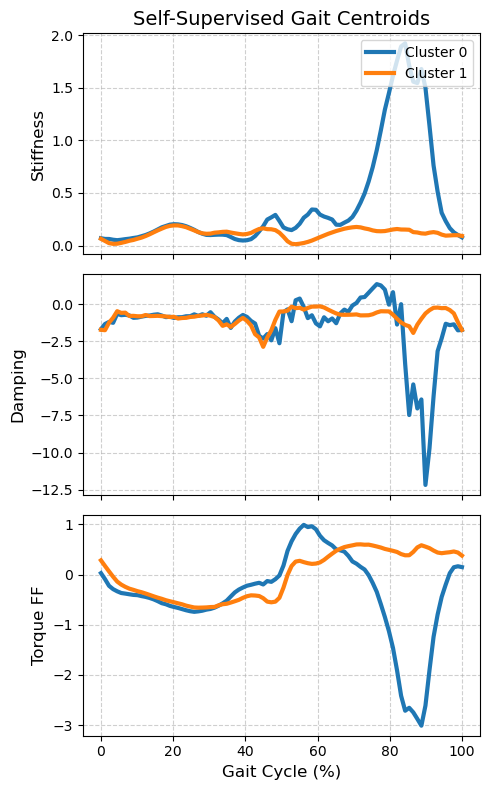

In [22]:
model.plot_centroids()

## Save model

In [23]:
model.save_model("environment_classifier_model.npz")

Model parameters saved to environment_classifier_model.npz
Saved 2 centroids, X_min: [ 5.54940524e-03 -3.00806313e+01 -6.19533539e+00], range_val: [ 3.56485298 39.10421944 10.29013348], window: 90
